# Ejercicio 3: Métricas de Evaluación de Modelos

Este notebook implementa un modelo de regresión logística para predecir la rotación de empleados (employee turnover) utilizando el dataset HR_comma_sep.csv.

## 1. Importación de Librerías

Importamos las librerías necesarias para el análisis:
- **sklearn**: Para modelos de machine learning y preprocesamiento
- **pandas**: Para manipulación de datos
- **numpy**: Para operaciones numéricas
- **matplotlib**: Para visualizaciones

In [1]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 2. Carga de Datos

Cargamos el dataset HR_comma_sep.csv que contiene información sobre empleados y si han dejado la empresa o no.

In [2]:
df = pd.read_csv('HR_comma_sep.csv')
df.sample(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
13282,0.97,0.50,3,216,3,0,0,0,IT,low
12980,0.79,0.92,4,208,2,1,0,0,marketing,low
6894,0.49,0.99,5,262,2,1,0,0,sales,medium
4103,0.31,0.54,5,259,5,1,0,0,technical,medium
11179,0.65,0.90,6,217,4,1,0,1,RandD,medium
8028,0.50,0.99,4,272,2,0,0,0,sales,medium
1833,0.10,0.85,6,266,4,0,1,0,sales,low
8832,0.25,0.80,5,186,4,1,0,0,support,medium
14682,0.44,0.53,2,149,3,0,1,0,sales,low
4486,0.76,0.79,3,161,3,0,0,0,technical,low


## 3. Selección de Variables

Seleccionamos las variables predictoras (features) y la variable objetivo (target):
- **X**: Variables independientes que usaremos para predecir
- **y**: Variable dependiente ('left') que indica si el empleado dejó la empresa (1) o no (0)

In [3]:
train_cols = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']
X = df[train_cols]
y = df['left']

## 4. División de Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba:
- **67%** para entrenamiento (train)
- **33%** para prueba (test)
- Usamos `random_state=42` para reproducibilidad

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## 5. Normalización de Datos

Aplicamos StandardScaler para estandarizar las variables:
- **fit_transform** en los datos de entrenamiento (aprende los parámetros y transforma)
- **transform** en los datos de prueba (solo aplica la transformación aprendida)

Esto asegura que todas las variables tengan media 0 y desviación estándar 1.

In [5]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test) 

## 6. Creación del Modelo

Creamos un modelo de Regresión Logística con:
- **C=1e10**: Parámetro de regularización muy alto (mínima regularización)

In [6]:
clf = LogisticRegression(C=1e10)


## 7. Entrenamiento del Modelo

Entrenamos el modelo de Regresión Logística con los datos de entrenamiento normalizados.

In [7]:
clf.fit(X_train, y_train)

LogisticRegression(C=10000000000.0)

## 8. Predicciones

Generamos predicciones sobre el conjunto de prueba utilizando el modelo entrenado.

In [8]:
y_pred=clf.predict(X_test)

## 9. Matriz de Confusión

Calculamos la matriz de confusión para visualizar los resultados de las predicciones:
- **Verdaderos Negativos (TN)**: Empleados que no dejaron la empresa y fueron predichos correctamente
- **Falsos Positivos (FP)**: Empleados que no dejaron la empresa pero fueron predichos como que sí lo hicieron
- **Falsos Negativos (FN)**: Empleados que dejaron la empresa pero fueron predichos como que no lo hicieron
- **Verdaderos Positivos (TP)**: Empleados que dejaron la empresa y fueron predichos correctamente

**Para qué se utiliza:**
- Base fundamental para calcular todas las demás métricas de clasificación
- Permite visualizar rápidamente dónde el modelo está cometiendo errores
- Ayuda a identificar si el modelo tiene sesgos hacia alguna clase específica
- Esencial para entender el rendimiento real del modelo más allá de la exactitud general

In [ ]:
from sklearn.metrics import confusion_matrix as confusion_matrix
confusion=confusion_matrix(y_test, y_pred)
print(confusion)

[[3466  303]
 [ 898  283]]


## 10. Accuracy (Exactitud)

La exactitud mide el porcentaje de predicciones correctas sobre el total de predicciones:
- **Fórmula**: (TP + TN) / (TP + TN + FP + FN)
- Indica qué tan bien el modelo clasifica en general

**Para qué se utiliza:**
- Métrica inicial para evaluar el rendimiento general del modelo
- Útil cuando las clases están **balanceadas** (similar cantidad de casos positivos y negativos)
- **No recomendado** para datasets desbalanceados, ya que puede ser engañosa
- Ejemplo: En detección de fraudes (1% fraudes), un modelo que siempre predice "no fraude" tendría 99% de accuracy pero sería inútil

In [13]:
from sklearn.metrics import accuracy_score

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7573737373737374


## 11. Análisis de la Clase Mayoritaria

Verificamos la distribución de clases en el conjunto de prueba para entender el balance de los datos.

**Para qué se utiliza:**
- Determinar si el dataset está balanceado o desbalanceado
- Establecer un baseline de comparación para el modelo
- Si las clases están muy desbalanceadas, un modelo que siempre prediga la clase mayoritaria tendría alta accuracy pero sería inútil
- Ayuda a decidir qué métricas son más apropiadas para evaluar el modelo

In [15]:
y_test.value_counts(normalize=True)

left
0    0.761414
1    0.238586
Name: proportion, dtype: float64

In [16]:
y_test.mean()

0.2385858585858586

## 12. Tasa de Error

La tasa de error representa el porcentaje de predicciones incorrectas:
- **Fórmula**: 1 - Accuracy
- Complementa la métrica de exactitud

**Para qué se utiliza:**
- Proporciona una perspectiva alternativa al accuracy (enfocándose en errores en lugar de aciertos)
- Útil para comunicar el rendimiento del modelo en términos de fallos
- Facilita la comparación con objetivos de negocio expresados en términos de tasas de error aceptables
- Ejemplo: "Necesitamos que el modelo tenga menos del 5% de tasa de error"

In [17]:
1.0 - y_test.mean()

0.7614141414141414

In [18]:
print(1-accuracy_score(y_test, y_pred))

0.24262626262626263


## 13. Recall (Sensibilidad)

El Recall o Sensibilidad mide la capacidad del modelo para identificar correctamente los casos positivos:
- **Fórmula**: TP / (TP + FN)
- Responde: "De todos los empleados que realmente dejaron la empresa, ¿cuántos detectamos?"
- Es crucial cuando el costo de los falsos negativos es alto

**Para qué se utiliza:**
- **Diagnóstico médico**: Detectar todas las enfermedades posibles (mejor un falso positivo que no detectar una enfermedad)
- **Detección de fraude**: Capturar todas las transacciones fraudulentas
- **Retención de empleados**: Identificar todos los empleados en riesgo de irse (como en este caso)
- **Spam**: Asegurar que todos los correos legítimos lleguen (incluso si algunos spam pasan)
- Se prioriza cuando es más costoso **NO detectar** un caso positivo que tener falsos positivos

In [19]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.23962743437764605


## 14. Specificity (Especificidad)

La Especificidad mide la capacidad del modelo para identificar correctamente los casos negativos:
- **Fórmula**: TN / (TN + FP)
- Responde: "De todos los empleados que realmente NO dejaron la empresa, ¿cuántos identificamos correctamente?"
- Complementa al Recall para tener una visión completa del rendimiento

**Para qué se utiliza:**
- **Screening de seguridad**: Evitar falsas alarmas que generen interrupciones innecesarias
- **Aprobación de créditos**: No rechazar a buenos clientes (evitar falsos positivos)
- **Control de calidad**: No desechar productos buenos por error
- **Diagnóstico de baja prevalencia**: Cuando la condición es rara, evitar alarmas falsas
- Se prioriza cuando es costoso tener **falsos positivos** (clasificar incorrectamente negativos como positivos)

In [21]:
TP = confusion[1, 1]
TN = confusion[0, 0]
FP = confusion[0, 1]
FN = confusion[1, 0]

specificity = TN / (TN + FP)
print("Specificity:", specificity)

Specificity: 0.9196073228973203


## 15. F1 Score

El F1 Score es la media armónica entre Precision y Recall:
- **Fórmula**: 2 × (Precision × Recall) / (Precision + Recall)
- Proporciona un balance entre Precision y Recall
- Es útil cuando queremos encontrar un equilibrio entre ambas métricas
- Particularmente valioso cuando las clases están desbalanceadas

**Para qué se utiliza:**
- **Datasets desbalanceados**: Proporciona una mejor evaluación que accuracy cuando hay desbalance de clases
- **Búsqueda de equilibrio**: Cuando tanto falsos positivos como falsos negativos son costosos
- **Comparación de modelos**: Métrica única que resume el rendimiento de clasificación
- **Detección de anomalías**: Donde necesitas balance entre detectar todas las anomalías (recall) y no tener demasiadas falsas alarmas (precision)
- Casos de uso: sistemas de recomendación, búsqueda de información, clasificación de textos, detección de objetos
- **Limitación**: No considera los verdaderos negativos (TN), por lo que puede no ser ideal en todos los contextos

In [22]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.3203169213355971


In [24]:
pd.Series(y_pred).unique()

array([0, 1])

In [25]:
pd.Series(y_pred).value_counts()

0    4364
1     586
Name: count, dtype: int64

## 16. Probabilidades de Predicción

Obtenemos las probabilidades de predicción del modelo en lugar de solo las clases binarias:
- **predict_proba()**: Devuelve la probabilidad de pertenencia a cada clase
- **Primera columna**: Probabilidad de clase 0 (no deja la empresa)
- **Segunda columna**: Probabilidad de clase 1 (deja la empresa)

**Para qué se utiliza:**
- Entender el nivel de confianza del modelo en sus predicciones
- Ajustar el umbral de decisión (threshold) según las necesidades del negocio
- Crear curvas ROC y calcular el AUC
- Priorizar casos según su probabilidad (ej: contactar primero a empleados con mayor probabilidad de irse)
- Obtener predicciones más granulares que solo 0 o 1

In [26]:
y_pred_proba=clf.predict_proba(X_test)

In [27]:
display(y_pred_proba.shape,y_pred_proba)

(4950, 2)

array([[0.96331411, 0.03668589],
       [0.93109665, 0.06890335],
       [0.81254066, 0.18745934],
       ...,
       [0.93393386, 0.06606614],
       [0.78966039, 0.21033961],
       [0.28278455, 0.71721545]])

In [28]:
pd.Series(y_pred).value_counts

<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       0
3       0
4       0
       ..
4945    0
4946    0
4947    0
4948    0
4949    1
Length: 4950, dtype: int64>

## 17. Visualización de Probabilidades

Creamos un histograma de las probabilidades predichas para la clase positiva (empleados que dejan la empresa).

**Para qué se utiliza:**
- Visualizar la distribución de confianza del modelo en sus predicciones
- Identificar si el modelo está polarizado (predicciones cercanas a 0 o 1) o es más conservador
- Detectar si hay suficiente separación entre clases
- Decidir si el threshold de 0.5 es apropiado o debería ajustarse
- Identificar casos en "zona gris" donde el modelo no está seguro

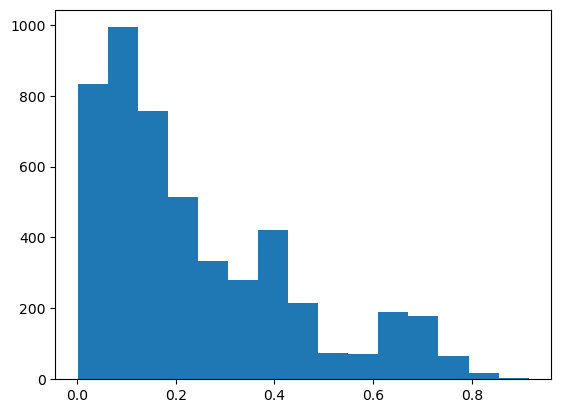

In [29]:
y_probs_logit_left = y_pred_proba[:, 1]
plt.hist(y_probs_logit_left, bins=15)
plt.xlim
plt.show()

## 18. Ajuste del Umbral de Decisión (Threshold)

Cambiamos el umbral de decisión de 0.5 (por defecto) a 0.3:
- Si la probabilidad de "left" ≥ 0.3, clasificamos como 1 (dejará la empresa)
- Si la probabilidad de "left" < 0.3, clasificamos como 0 (no dejará la empresa)

**Para qué se utiliza:**
- **Aumentar Recall**: Un threshold más bajo (como 0.3) identifica más casos positivos, aumentando la sensibilidad
- **Reducir falsos negativos**: Útil cuando es crítico no perder ningún empleado en riesgo
- **Casos de uso prácticos**: 
  - Programas de retención: Mejor incluir más empleados (algunos falsos positivos) que perder empleados valiosos
  - Detección temprana: Actuar preventivamente con mayor margen de seguridad
  - Balance costo-beneficio: Cuando retener un empleado es más valioso que el costo de falsos positivos
- **Trade-off**: Aumenta falsos positivos pero reduce falsos negativos

In [30]:
y_pred_logit= (y_probs_logit_left >= 0.3).astype(int)
y_pred_logit

array([0, 0, 0, ..., 0, 0, 1])

## 19. Comparación de Matrices de Confusión

Comparamos las matrices de confusión con diferentes thresholds:
- **Threshold 0.5** (por defecto): Predicciones originales
- **Threshold 0.3**: Predicciones con umbral ajustado

**Para qué se utiliza:**
- Evaluar el impacto del cambio de threshold en las predicciones
- Visualizar cómo cambian TP, TN, FP y FN con diferentes umbrales
- Tomar decisiones informadas sobre qué threshold usar según el contexto del negocio
- Entender el trade-off entre sensibilidad y especificidad

In [34]:
from sklearn.metrics import confusion_matrix
display(confusion_matrix(y_test, y_pred))
display(confusion_matrix(y_test, y_pred_logit))


array([[3466,  303],
       [ 898,  283]])

array([[3046,  723],
       [ 358,  823]])

## 20. Comparación de Accuracy

Comparamos la exactitud del modelo con ambos thresholds para ver cómo afecta el cambio de umbral al rendimiento general.

**Para qué se utiliza:**
- Cuantificar el impacto del threshold en la métrica general de accuracy
- Entender que un threshold más bajo puede reducir la accuracy general pero mejorar otras métricas importantes
- Recordatorio: Accuracy no siempre es la métrica más importante; depende del contexto del negocio

In [36]:
print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred_logit))

0.7573737373737374
0.7816161616161617


## 21. Curva ROC (Receiver Operating Characteristic)

Calculamos los puntos de la curva ROC:
- **FPR (False Positive Rate)**: Tasa de falsos positivos = FP / (FP + TN) = 1 - Specificity
- **TPR (True Positive Rate)**: Tasa de verdaderos positivos = TP / (TP + FN) = Recall/Sensitivity
- **Thresholds**: Diferentes umbrales de decisión evaluados

**Para qué se utiliza:**
- **Evaluar rendimiento independiente del threshold**: Muestra el rendimiento del modelo en todos los posibles umbrales
- **Comparar modelos**: Identificar qué modelo tiene mejor capacidad de discriminación
- **Seleccionar threshold óptimo**: Elegir el punto en la curva que mejor balance las necesidades del negocio
- **Visualizar trade-off**: Entre TPR (recall) y FPR (1-specificity)
- Útil para modelos de clasificación binaria donde el threshold es ajustable

In [37]:
from sklearn.metrics import roc_curve

In [40]:
fpr_log, tpr_log, thr_log = roc_curve(y_test, y_pred_proba[:,1])
pd.DataFrame(dict(fpr=fpr_log,tpr=tpr_log,thr=thr_log))

,fpr,tpr,thr
0,0.000000,0.000000,inf
1,0.000531,0.000000,0.915169
2,0.001061,0.000000,0.856451
3,0.001061,0.000847,0.844059
4,0.002123,0.000847,0.825634
...,...,...,...
1390,0.980101,0.999153,0.014861
1391,0.981162,0.999153,0.014761
1392,0.984081,0.999153,0.013440
1393,0.984081,1.000000,0.013227


## 22. Visualización de la Curva ROC

Graficamos la curva ROC completa:
- **Eje X**: 1 - Specificity (FPR) - Tasa de falsos positivos
- **Eje Y**: Sensitivity (TPR) - Tasa de verdaderos positivos (Recall)
- **Línea diagonal**: Representa un clasificador aleatorio (sin poder predictivo)
- **Curva del modelo**: Muestra el rendimiento real del modelo

**Para qué se utiliza:**
- **Evaluación visual del modelo**: 
  - Curva cerca de la esquina superior izquierda = Excelente modelo
  - Curva cerca de la diagonal = Modelo sin poder predictivo (tan bueno como adivinar)
  - Área entre la curva y la diagonal = Poder predictivo del modelo
- **Selección de threshold**: Cada punto en la curva representa un threshold diferente
- **Comparación de modelos**: Superponer múltiples curvas ROC para elegir el mejor modelo
- **Comunicación con stakeholders**: Visualización intuitiva del rendimiento del modelo
- Muy utilizada en medicina, finanzas, y cualquier aplicación donde el threshold es crítico

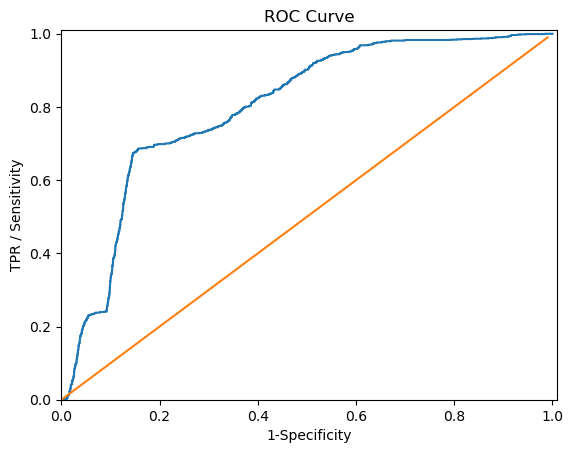

In [44]:
df = pd.DataFrame(dict(fpr=fpr_log,tpr=tpr_log,thr=thr_log))
plt.axis([0,1.01,0,1.01])
plt.xlabel("1-Specificity")
plt.ylabel("TPR / Sensitivity")
plt.title("ROC Curve")
plt.plot(df['fpr'],df['tpr'])
plt.plot(np.arange(0,1,step=0.01),np.arange(0,1,step=0.01))
plt.show()

## 23. AUC (Area Under the Curve)

Calculamos el AUC-ROC, que es el área bajo la curva ROC:
- **Rango**: De 0 a 1
- **1.0**: Clasificador perfecto
- **0.5**: Clasificador aleatorio (sin poder predictivo)
- **< 0.5**: Peor que aleatorio (el modelo está invirtiendo las predicciones)

**Para qué se utiliza:**
- **Métrica única de rendimiento**: Resume toda la curva ROC en un solo número
- **Comparación de modelos**: Facilita comparar múltiples modelos objetivamente
- **Independiente del threshold**: Evalúa la capacidad general del modelo de discriminar entre clases
- **Interpretación práctica**:
  - **0.9 - 1.0**: Excelente discriminación
  - **0.8 - 0.9**: Buena discriminación
  - **0.7 - 0.8**: Discriminación aceptable
  - **0.6 - 0.7**: Pobre discriminación
  - **0.5 - 0.6**: Muy pobre discriminación
- **Ventajas**: 
  - Robusto ante desbalance de clases
  - No requiere seleccionar un threshold específico
  - Ampliamente aceptado en la industria
- **Casos de uso**: Modelos de riesgo crediticio, diagnóstico médico, detección de fraude, scoring de clientes

In [45]:
from sklearn.metrics import auc
print(auc(fpr_log, tpr_log))

0.7999521026853724
